## Load Packages and Data

In [ ]:
import pandas as pd
from pybaseball import statcast
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from scipy import linalg
import itertools
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import requests
import math as math
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.lines as mlines
import warnings

from distances import compute_mahalanobis_distances, compute_euclidean_distances

# Set option to display all columns
pd.set_option('display.max_columns', None)

warnings.filterwarnings("ignore")


In [ ]:
#statcast_25 = statcast(start_dt="2025-01-01", end_dt="2025-12-31")
#statcast_25 = statcast_25[statcast_25['game_type']=='R']
#statcast_25.to_csv('/Users/kids/Desktop/2025_statcast.csv', index=False)

In [ ]:
#statcast_2124 = statcast(start_dt="2021-01-01", end_dt="2024-12-31")
#statcast_2124 = statcast_2124[statcast_2124['game_type']=='R']
#statcast_2124.to_csv('/Users/kids/Desktop/2021-24_statcast_update.csv', index=False)

In [2]:
statcast_25 = pd.read_csv('/Users/kids/Desktop/Sports Projects/Pitcher Similarity/2025_statcast.csv')
statcast_2124 = pd.read_csv('/Users/kids/Desktop/Sports Projects/Pitcher Similarity/2021-24_statcast_update.csv')

In [3]:
statcast_data = pd.concat([statcast_2124, statcast_25])
statcast_data.shape

(3567640, 118)

## Data Cleaning

In [4]:
# Filter out eephus and other unusually slow pitches
statcast_clean = statcast_data[statcast_data['release_speed'] >= 70]


In [5]:
name_key = statcast_clean[['pitcher', 'player_name']].drop_duplicates().reset_index(drop=True)

In [6]:
pitch_type_columns = ['pitch_type', 'pitcher', 'player_name', 'release_speed', 'release_pos_x', 
                      'release_pos_z', 'p_throws', 'pfx_x', 'pfx_z', 'release_spin_rate',
                      'release_extension', 'release_pos_y', 'spin_axis', 'arm_angle',
                      'game_year']

In [7]:
pitch_type_summ = statcast_clean[pitch_type_columns].groupby(['pitch_type', 'pitcher', 'player_name', 'p_throws', 'game_year']).mean().reset_index()
counts = (
    statcast_clean
    .groupby(['pitch_type', 'pitcher', 'player_name', 'p_throws', 'game_year'])
    .size()
    .reset_index(name='n')
)
pitch_type_summ = pitch_type_summ.merge(counts, on=['pitch_type', 'pitcher', 'p_throws', 'player_name', 'game_year'])

In [8]:
pitch_type_summ.head()

,pitch_type,pitcher,player_name,p_throws,game_year,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,release_spin_rate,release_extension,release_pos_y,spin_axis,arm_angle,n
0,CH,425794,"Wainwright, Adam",R,2021,82.729744,-1.333487,6.222359,-1.152821,0.643179,1714.097938,6.495897,54.000974,222.546392,43.993229,195
1,CH,425794,"Wainwright, Adam",R,2022,82.182540,-1.314709,6.223757,-1.192593,0.668889,1763.634921,6.424339,54.075979,225.285714,42.871429,189
2,CH,425794,"Wainwright, Adam",R,2023,81.431461,-1.335618,6.142360,-1.168652,0.729663,1655.179775,6.511236,53.991685,225.898876,42.803529,89
3,CH,425844,"Greinke, Zack",R,2021,86.350791,-1.371002,6.311160,-1.065747,0.371793,1593.499115,5.907381,54.591810,225.651327,43.748592,569
4,CH,425844,"Greinke, Zack",R,2022,86.468984,-1.825642,6.142861,-1.067433,0.317032,1643.493298,5.916845,54.583316,229.329759,39.724722,374


In [ ]:
# No longer needed

def fetch_player_heights(mlbam_ids):
    """
    Fetch height in inches for a list of MLBAM player IDs.
    Batches requests to avoid URL length limits.
    
    Parameters:
        mlbam_ids : list of MLBAM player IDs
    Returns:
        DataFrame with columns: pitcher, height_in
    """
    batch_size = 500
    records = []
    
    for i in range(0, len(mlbam_ids), batch_size):
        batch = mlbam_ids[i:i + batch_size]
        ids_str = ','.join(str(x) for x in batch)
        url = f"https://statsapi.mlb.com/api/v1/people?personIds={ids_str}&fields=people,id,height"
        response = requests.get(url)
        response.raise_for_status()
        
        for person in response.json().get('people', []):
            height_str = person.get('height', '')
            try:
                feet, inches = height_str.replace('"', '').split("' ")
                height_in = int(feet) * 12 + int(inches)
            except (ValueError, AttributeError):
                height_in = None
            records.append({
                'pitcher': person.get('id'),
                'height_in': height_in
            })
    
    return pd.DataFrame(records)

height_key = fetch_player_heights(statcast_clean['pitcher'].drop_duplicates().tolist())

#### Spin Efficiency Download

In [9]:
csv_path = '/Users/kids/Pitcher Similarity/Spin Files/'
spin_25 = pd.read_csv(csv_path+'active-spin_25.csv')
spin_24 = pd.read_csv(csv_path+'active-spin_24.csv')
spin_23 = pd.read_csv(csv_path+'active-spin_23.csv')
spin_22 = pd.read_csv(csv_path+'active-spin_22.csv')
spin_21 = pd.read_csv(csv_path+'active-spin_21.csv')
spin_25['year'] = 2025
spin_24['year'] = 2024
spin_23['year'] = 2023
spin_22['year'] = 2022
spin_21['year'] = 2021
spin_df = pd.concat([spin_21, spin_22, spin_23, spin_24, spin_25])

In [10]:
spin_df.head()

,entity_name,entity_id,pitch_hand,active_spin_fourseam,active_spin_sinker,active_spin_cutter,active_spin_changeup,active_spin_splitter,active_spin_curve,active_spin_slider,active_spin_sweeper,active_spin_slurve,year
0,"Kintzler, Brandon",445213,R,NaN,92.3,NaN,96.6,NaN,NaN,17.7,NaN,NaN,2021
1,"Clay, Sam",621348,L,NaN,90.9,NaN,88.6,NaN,NaN,33.2,NaN,NaN,2021
2,"Suero, Wander",593833,R,NaN,NaN,60.0,69.4,NaN,71.2,NaN,NaN,NaN,2021
3,"Bummer, Aaron",607481,L,NaN,83.1,16.5,NaN,NaN,NaN,NaN,82.1,NaN,2021
4,"Poppen, Sean",664092,R,NaN,94.7,NaN,96.7,NaN,NaN,61.2,NaN,NaN,2021


In [12]:
# Define conditions
conditions = [
    (~spin_df['active_spin_fourseam'].isna()),
    (spin_df['active_spin_fourseam'].isna() & ~spin_df['active_spin_sinker'].isna())
]

# Define corresponding results
choices = [spin_df['active_spin_fourseam'], spin_df['active_spin_sinker']]
choices_type = ['FF', 'SI']

# Create column (with a default value for anything not met)
spin_df['active_spin_fastball'] = np.select(conditions, choices, default=spin_df['active_spin_cutter'])
spin_df['FB_type'] = np.select(conditions, choices_type, default='FC')
spin_df['pitcher'] = spin_df['entity_id']

In [13]:
spin_df_join = spin_df[['pitcher', 'active_spin_fastball', 'FB_type', 'year']]

In [14]:
spin_df_join.head()

,pitcher,active_spin_fastball,FB_type,year
0,445213,92.3,SI,2021
1,621348,90.9,SI,2021
2,593833,60.0,FC,2021
3,607481,83.1,SI,2021
4,664092,94.7,SI,2021


#### Aggregate to pitcher level

In [15]:
pitcher_summ = statcast_clean.groupby(['pitcher', 'p_throws', 'player_name', 'game_year']).agg(
    release_pos_x=('release_pos_x','mean'),
    release_pos_z=('release_pos_z','mean'),
    release_extension=('release_extension','mean'),
    arm_angle=('arm_angle','mean'),
    n=('pitcher','size')
).reset_index()

pitch_chars = pitch_type_summ.groupby(['pitcher', 'p_throws', 'game_year']).agg(
    max_velo=('release_speed','max'),
    max_spin=('release_spin_rate','max')
).reset_index()

# Get FF and SI pitches only, find most thrown fastball per pitcher
fastball_counts = (
    pitch_type_summ[pitch_type_summ['pitch_type'].isin(['FF', 'SI'])]
    .sort_values('n', ascending=False)
    .groupby(['pitcher', 'game_year'])
    .first()
    .reset_index()
    [['pitcher', 'game_year', 'pitch_type', 'pfx_x', 'n']]
    .rename(columns={'pfx_x': 'fb_pfx_x', 'pitch_type': 'pri_fb', 'n': 'fb_n'})
)

#pitcher_summ = pitcher_summ.merge(height_key, on=['pitcher'], how='left')
pitcher_summ = pitcher_summ.merge(pitch_chars, on=['pitcher', 'p_throws', 'game_year'])
pitcher_summ = pitcher_summ.merge(fastball_counts, on=['pitcher', 'game_year'], how='left')
pitcher_summ['pri_fb_cd'] = (pitcher_summ['pri_fb'] == 'FF').astype(int)
pitcher_summ = pitcher_summ.merge(spin_df_join, left_on=['pitcher', 'game_year'], right_on=['pitcher', 'year'], how='left').drop(columns='year')

pitcher_summ_r = pitcher_summ[pitcher_summ['p_throws']=='R']
pitcher_summ_l = pitcher_summ[pitcher_summ['p_throws']=='L']

pitcher_summ_25 = pitcher_summ[pitcher_summ['game_year']==2025]
pitcher_summ_r_25 = pitcher_summ_r[pitcher_summ_r['game_year']==2025]
pitcher_summ_l_25 = pitcher_summ_l[pitcher_summ_l['game_year']==2025]

In [16]:
pitcher_summ.head()

,pitcher,p_throws,player_name,game_year,release_pos_x,release_pos_z,release_extension,arm_angle,n,max_velo,max_spin,pri_fb,fb_pfx_x,fb_n,pri_fb_cd,active_spin_fastball,FB_type
0,424144,L,"Pérez, Oliver",2021,2.390893,5.429286,6.178571,22.013043,56,89.211538,2111.055556,SI,1.583846,26.0,0,NaN,NaN
1,424144,L,"Pérez, Oliver",2022,2.498630,5.361370,6.134247,19.002740,73,88.750000,2255.851852,SI,1.468636,44.0,0,NaN,NaN
2,425794,R,"Wainwright, Adam",2021,-1.195318,6.292470,6.478433,46.499203,3037,89.050985,2840.411298,SI,-1.061773,863.0,0,76.4,FF
3,425794,R,"Wainwright, Adam",2022,-1.119490,6.303870,6.419000,46.148490,3080,88.566476,2777.854856,SI,-1.085446,874.0,0,75.8,FF
4,425794,R,"Wainwright, Adam",2023,-1.246479,6.218935,6.475293,45.361083,1690,86.875000,2663.096110,SI,-1.104411,560.0,0,76.9,FF


#### Non Standardized dataframe for Mahalanobis Distance comp

In [17]:
pitch_type_clean_r = pitch_type_summ[pitch_type_summ['p_throws']=='R'][['player_name','pitch_type','release_speed','pfx_x','pfx_z','n']]
pitch_type_clean_r.shape

(13785, 6)

In [18]:
pitch_type_clean_r.head()

,player_name,pitch_type,release_speed,pfx_x,pfx_z,n
0,"Wainwright, Adam",CH,82.729744,-1.152821,0.643179,195
1,"Wainwright, Adam",CH,82.182540,-1.192593,0.668889,189
2,"Wainwright, Adam",CH,81.431461,-1.168652,0.729663,89
3,"Greinke, Zack",CH,86.350791,-1.065747,0.371793,569
4,"Greinke, Zack",CH,86.468984,-1.067433,0.317032,374


In [19]:
pitch_type_clean_l = pitch_type_summ[pitch_type_summ['p_throws']=='L'][['player_name','pitch_type','release_speed','pfx_x','pfx_z','n']]
pitch_type_clean_l.shape

(4775, 6)

#### Standardized Pitch Dataframe for Euclidean Distance

In [20]:
pitch_type_z_r = pitch_type_summ[pitch_type_summ['p_throws']=='R'][['player_name','game_year','pitch_type','release_speed','pfx_x','pfx_z','n']]
print(pitch_type_z_r.shape)
pitch_type_z_r.head()

(13785, 7)


,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n
0,"Wainwright, Adam",2021,CH,82.729744,-1.152821,0.643179,195
1,"Wainwright, Adam",2022,CH,82.182540,-1.192593,0.668889,189
2,"Wainwright, Adam",2023,CH,81.431461,-1.168652,0.729663,89
3,"Greinke, Zack",2021,CH,86.350791,-1.065747,0.371793,569
4,"Greinke, Zack",2022,CH,86.468984,-1.067433,0.317032,374


In [21]:
pitch_type_z_l = pitch_type_summ[pitch_type_summ['p_throws']=='L'][['player_name','game_year','pitch_type','release_speed','pfx_x','pfx_z','n']]
print(pitch_type_z_l.shape)

(4775, 7)


## Mahalanobis Distance

Not updated for game_year

In [23]:
pitch_type_distance_r = compute_mahalanobis_distances(pitch_type_clean_r, 
                                                      features=["release_speed", "pfx_x", "pfx_z"], 
                                                      label_cols=["player_name", "pitch_type"], 
                                                      min_pitches = 100)
pitch_type_distance_l = compute_mahalanobis_distances(pitch_type_clean_l, 
                                                      features=["release_speed", "pfx_x", "pfx_z"], 
                                                      label_cols=["player_name", "pitch_type"], 
                                                      min_pitches = 100)

In [24]:
pitch_type_distance_r

,player_name1,player_name2,pitch_type1,pitch_type2,distance
0,"Houck, Tanner","Clarke, Taylor",SL,ST,0.002682
1,"Cruz, Fernando","Oviedo, Luis",FF,FF,0.006077
2,"Miller, Shelby","Heasley, Jonathan",FF,FF,0.006110
3,"Houser, Adrian","Underwood Jr., Duane",FF,FF,0.006859
4,"Severino, Luis","Hendricks, Kyle",CH,SI,0.007338
...,...,...,...,...,...
23191450,"Cano, Yennier","Rogers, Tyler",SI,SL,9.183685
23191451,"Cano, Yennier","Rogers, Tyler",SI,SL,9.257274
23191452,"Cano, Yennier","Rogers, Tyler",SI,SL,9.387088
23191453,"Cano, Yennier","Rogers, Tyler",SI,SL,9.388102


In [25]:
pitch_type_distance_r[((pitch_type_distance_r['player_name1']=='Meyer, Max') | (pitch_type_distance_r['player_name2']=='Meyer, Max')) &
    ((pitch_type_distance_r['player_name1']=='Adam, Jason') | (pitch_type_distance_r['player_name2']=='Adam, Jason'))] \
    .sort_values(['player_name1', 'pitch_type1'])

,player_name1,player_name2,pitch_type1,pitch_type2,distance
30777,"Adam, Jason","Meyer, Max",CH,CH,0.166101
82943,"Adam, Jason","Meyer, Max",CH,CH,0.236835
165634,"Adam, Jason","Meyer, Max",CH,CH,0.306876
861331,"Adam, Jason","Meyer, Max",CH,CH,0.601865
3142686,"Adam, Jason","Meyer, Max",CH,SI,1.121388
...,...,...,...,...,...
12344425,"Meyer, Max","Adam, Jason",SL,ST,2.288890
12515767,"Meyer, Max","Adam, Jason",SL,ST,2.307554
14912413,"Meyer, Max","Adam, Jason",SL,ST,2.579141
16262733,"Meyer, Max","Adam, Jason",SL,ST,2.745877


### Data Exploration Pitch Characteristics

Note: pitch_type_clean_r not updated for game_year nor normalized

In [40]:
pitch_type_clean_r.head()

,player_name,pitch_type,release_speed,pfx_x,pfx_z,n
0,"Wainwright, Adam",CH,82.729744,-1.152821,0.643179,195
1,"Wainwright, Adam",CH,82.182540,-1.192593,0.668889,189
2,"Wainwright, Adam",CH,81.431461,-1.168652,0.729663,89
3,"Greinke, Zack",CH,86.350791,-1.065747,0.371793,569
4,"Greinke, Zack",CH,86.468984,-1.067433,0.317032,374


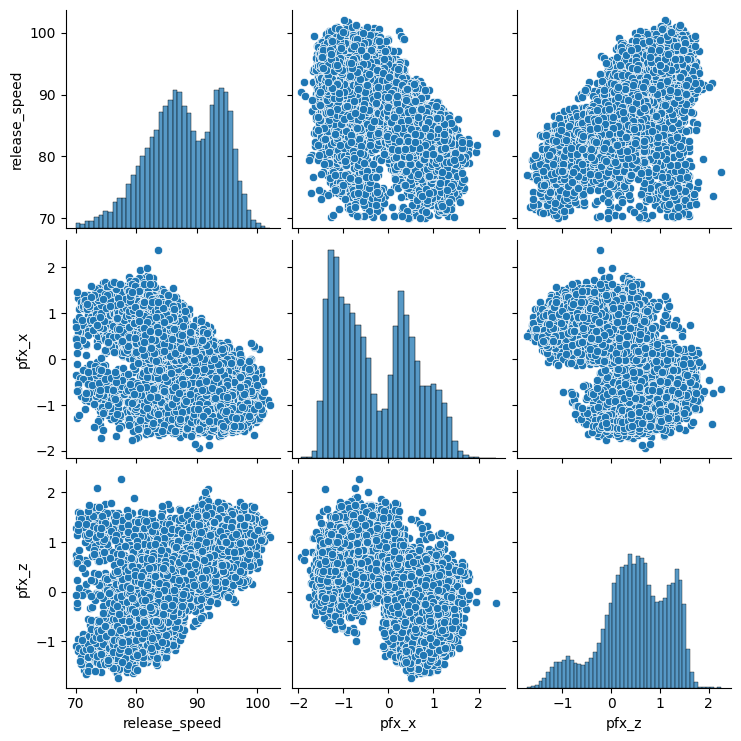

In [26]:
sns.pairplot(
    pitch_type_clean_r,
    vars=["release_speed", "pfx_x", "pfx_z"],
    #hue="pitch_type"
)
plt.show()

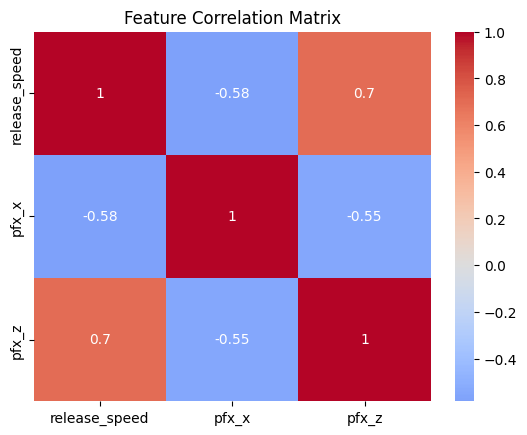

In [27]:
corr = pitch_type_clean_r[["release_speed", "pfx_x", "pfx_z"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

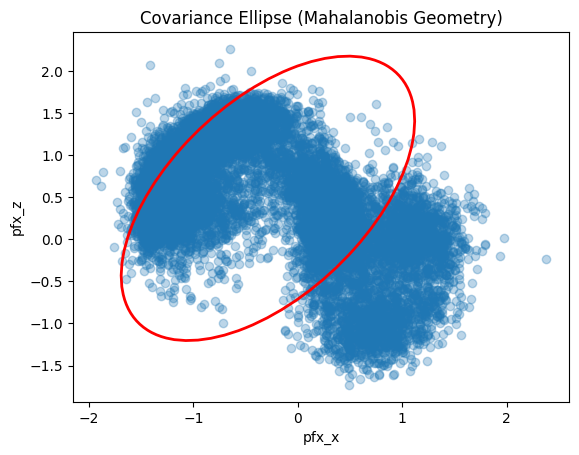

In [28]:
X = pitch_type_clean_r[["pfx_x", "pfx_z"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("pfx_x")
ax.set_ylabel("pfx_z")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()

In [29]:
X = pitch_type_clean_r[["release_speed", "pfx_x", "pfx_z"]].dropna().values
VI = np.linalg.pinv(np.cov(X, rowvar=False))

def mahalanobis_components(x, y, VI):
    diff = x - y
    return diff * (VI @ diff)

# Example: inspect a weird pair
i, j = 0, 1  # replace with a suspicious pair
comp = mahalanobis_components(X[i], X[j], VI)

pd.Series(comp, index=["release_speed", "pfx_x", "pfx_z"])

release_speed    0.025352
pfx_x            0.005542
pfx_z            0.006024
dtype: float64

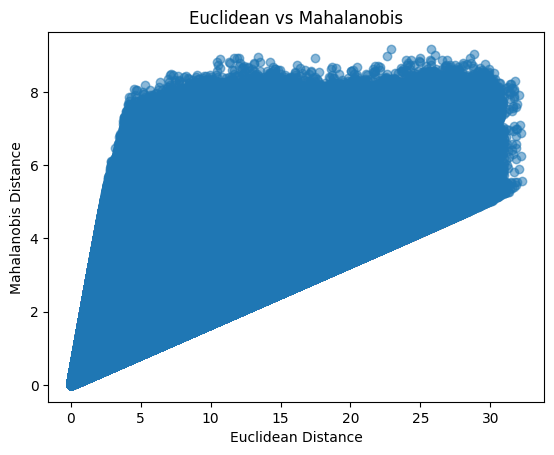

In [30]:
X = pitch_type_clean_r[["release_speed", "pfx_x", "pfx_z"]].dropna().values

euclidean = cdist(X, X, metric="euclidean")
mahal = cdist(X, X, metric="mahalanobis", VI=np.linalg.pinv(np.cov(X, rowvar=False)))

plt.scatter(euclidean.flatten(), mahal.flatten(), alpha=0.3)
plt.xlabel("Euclidean Distance")
plt.ylabel("Mahalanobis Distance")
plt.title("Euclidean vs Mahalanobis")
plt.show()

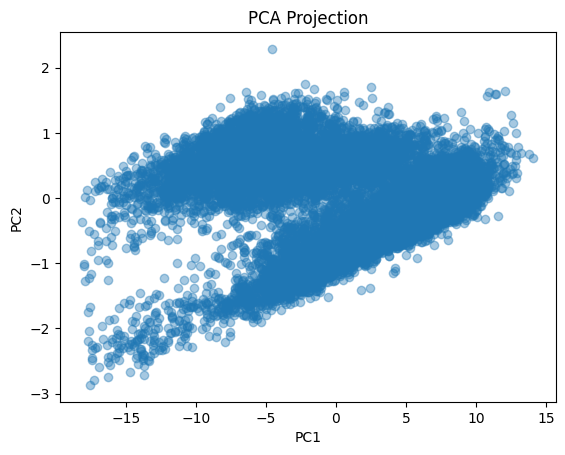

In [31]:
X = pitch_type_clean_r[["release_speed", "pfx_x", "pfx_z"]].dropna().values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

### Data Exploration Biomechanics

In [33]:
pitcher_summ_r.head()

,pitcher,p_throws,player_name,game_year,release_pos_x,release_pos_z,release_extension,arm_angle,n,max_velo,max_spin,pri_fb,fb_pfx_x,fb_n,pri_fb_cd,active_spin_fastball,FB_type
2,425794,R,"Wainwright, Adam",2021,-1.195318,6.292470,6.478433,46.499203,3037,89.050985,2840.411298,SI,-1.061773,863.0,0,76.4,FF
3,425794,R,"Wainwright, Adam",2022,-1.119490,6.303870,6.419000,46.148490,3080,88.566476,2777.854856,SI,-1.085446,874.0,0,75.8,FF
4,425794,R,"Wainwright, Adam",2023,-1.246479,6.218935,6.475293,45.361083,1690,86.875000,2663.096110,SI,-1.104411,560.0,0,76.9,FF
5,425844,R,"Greinke, Zack",2021,-1.271575,6.362570,5.938383,47.284900,2463,89.495973,2406.351852,FF,-0.107953,1026.0,1,78.7,FF
6,425844,R,"Greinke, Zack",2022,-1.725025,6.204550,5.905016,42.991710,2213,89.450000,2447.595238,FF,-0.173206,867.0,1,79.2,FF


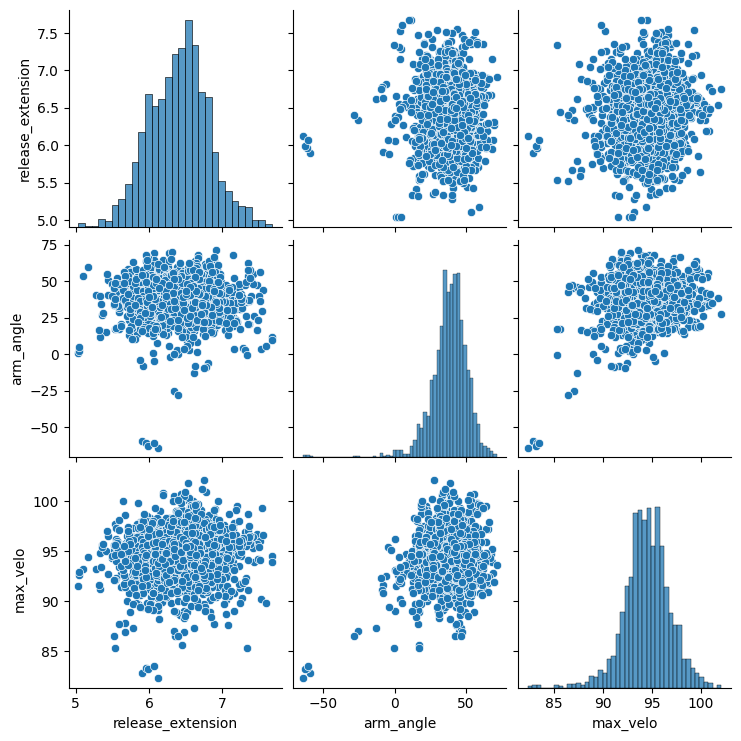

In [34]:
sns.pairplot(
    pitcher_summ_r[pitcher_summ_r['n']>500],
    vars=['release_extension', 'arm_angle', 'max_velo'],
    #hue="pitch_type"
)
plt.show()

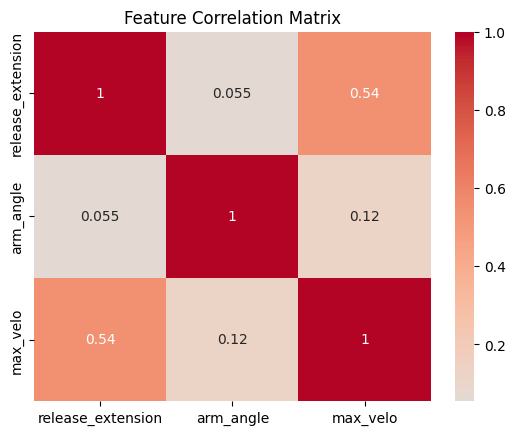

In [35]:
corr = pitcher_summ_r[['release_extension', 'arm_angle', 'max_velo']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

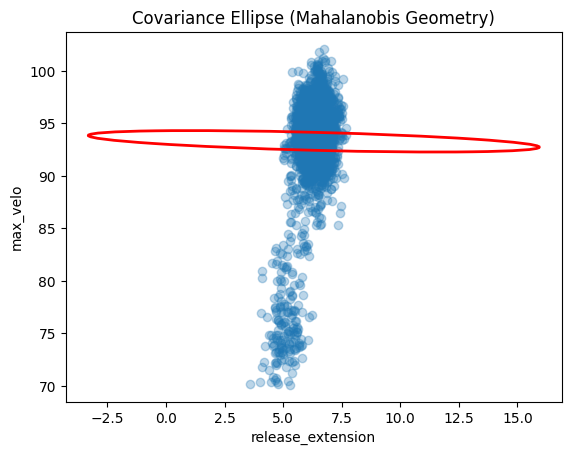

In [36]:
X = pitcher_summ_r[["release_extension", "max_velo"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("release_extension")
ax.set_ylabel("max_velo")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()

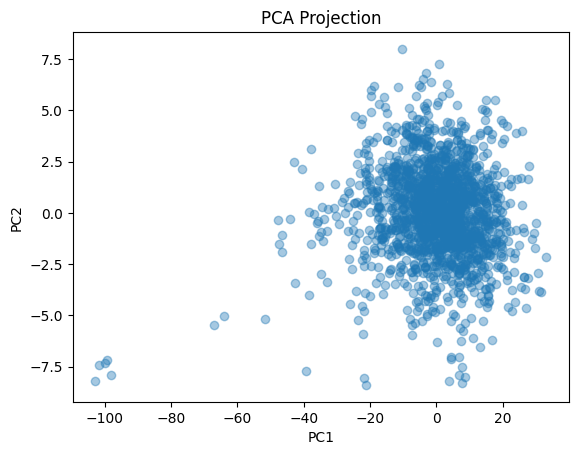

In [37]:
X = pitcher_summ_r[pitcher_summ_r['n']>500][['release_extension', 'arm_angle', 'max_velo']].dropna().values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

## Standardized Euclidean Distance

In [39]:
pitch_type_distance_z_r = compute_euclidean_distances(pitch_type_z_r, 
                                                      features=["release_speed", "pfx_x", "pfx_z"], 
                                                      label_cols=["player_name", "pitch_type", "game_year"], 
                                                      min_pitches = 20)
pitch_type_distance_z_l = compute_euclidean_distances(pitch_type_z_l, 
                                                      features=["release_speed", "pfx_x", "pfx_z"], 
                                                      label_cols=["player_name", "pitch_type", "game_year"], 
                                                      min_pitches = 20)

In [41]:
pitch_type_distance_z_r_25 = pitch_type_distance_z_r[(pitch_type_distance_z_r['game_year1']==2025) & 
    (pitch_type_distance_z_r['game_year2']==2025)]
pitch_type_distance_z_l_25 = pitch_type_distance_z_l[(pitch_type_distance_z_l['game_year1']==2025) & 
    (pitch_type_distance_z_l['game_year2']==2025)]

In [42]:
print(pitch_type_distance_z_r.shape)
pitch_type_distance_z_r.head()

(56333805, 7)


,player_name1,player_name2,pitch_type1,pitch_type2,game_year1,game_year2,distance
0,"Lyles, Jordan","Feyereisen, J.P.",FC,SL,2021,2021,0.002326
1,"Houck, Tanner","Clarke, Taylor",SL,ST,2023,2023,0.002671
2,"Cruz, Fernando","Oviedo, Luis",FF,FF,2023,2021,0.003506
3,"Miller, Shelby","Heasley, Jonathan",FF,FF,2023,2021,0.004015
4,"Greene, Hunter","Miller, Bobby",FF,FF,2024,2025,0.004723


In [43]:
print(pitch_type_distance_z_r_25.shape)
pitch_type_distance_z_r_25.head()

(2554930, 7)


,player_name1,player_name2,pitch_type1,pitch_type2,game_year1,game_year2,distance
6,"Severino, Luis","Hendricks, Kyle",CH,SI,2025,2025,0.005245
44,"Santana, Dennis","Oviedo, Johan",CH,CH,2025,2025,0.012167
52,"Enright, Nic","Hernández, Carlos",CU,KC,2025,2025,0.012540
56,"Woodford, Jake","Cecconi, Slade",FC,FC,2025,2025,0.012769
87,"Seabold, Connor","Martinez, Nick",FF,SI,2025,2025,0.014664


In [44]:
# pitch_type_distance_z_r[((pitch_type_distance_z_r['player_name1']=='Meyer, Max') | (pitch_type_distance_z_r['player_name2']=='Meyer, Max')) &
#     ((pitch_type_distance_z_r['player_name1']=='Adam, Jason') | (pitch_type_distance_z_r['player_name2']=='Adam, Jason'))] \
#     .sort_values(['player_name1', 'pitch_type1'])

## Arsenal Comparison

In [45]:
def compare_all_arsenals(pitch_distances, penalty_pctile):
    """
    Compute pairwise arsenal distances for all pitcher pairs.

    Parameters:
        pitch_distances : long-form DataFrame output from compute_mahalanobis_distances()
        penalty_pctile  : default penalty when the pitchers have different size arsenals

    Returns:
        Long-form DataFrame with columns pitcher1, pitcher2, arsenal_distance
    """
    unmatched_penalty = np.percentile(pitch_distances["distance"], penalty_pctile)
    print(unmatched_penalty)

    # Build a lookup dict: (pitcher1, pitch_type1, pitcher2, pitch_type2) -> distance
    # Store both directions so we don't need to flip later
    dist_lookup = {}
    for row in pitch_distances.itertuples(index=False):
        dist_lookup[(row.player_name1, row.game_year1, row.pitch_type1,
                     row.player_name2, row.game_year2, row.pitch_type2)] = row.distance
        dist_lookup[(row.player_name2, row.game_year2, row.pitch_type2,
                     row.player_name1, row.game_year1, row.pitch_type1)] = row.distance

    # Build a dict: pitcher -> list of pitch types
    pitcher_pitches = (
        pitch_distances[["player_name1", "game_year1", "pitch_type1"]]
        .rename(columns={"player_name1": "player_name", "game_year1":"game_year", "pitch_type1": "pitch_type"})
        .drop_duplicates()
        .groupby(["player_name", "game_year"])["pitch_type"]
        .apply(list)
        .to_dict()
    )

    pitcher_years = list(pitcher_pitches.keys())  # list of (player_name, game_year) tuples
    results = []

    for (p1, y1), (p2, y2) in itertools.combinations(pitcher_years, 2):
        pitches1 = pitcher_pitches[(p1, y1)]
        pitches2 = pitcher_pitches[(p2, y2)]
        n1, n2 = len(pitches1), len(pitches2)
        n = max(n1, n2)

        # Build cost matrix with unmatched penalty as default
        cost_matrix = np.full((n, n), unmatched_penalty)
        for i, pt1 in enumerate(pitches1):
            for j, pt2 in enumerate(pitches2):
                key = (p1, y1, pt1, p2, y2, pt2)
                if key in dist_lookup:
                    cost_matrix[i, j] = dist_lookup[key]

        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        avg_distance = cost_matrix[row_ind, col_ind].sum() / n
        results.append((p1, y1, p2, y2, avg_distance))

    return (
        pd.DataFrame(results, columns=["player_name1", "game_year1", "player_name2", "game_year2", "arsenal_distance"])
        .sort_values("arsenal_distance")
        .reset_index(drop=True)
    )

In [46]:
arsenal_comp_l_25 = compare_all_arsenals(pitch_type_distance_z_l_25, 50)
arsenal_comp_r_25 = compare_all_arsenals(pitch_type_distance_z_r_25, 50)

2.013743173850861
2.0162059293092662


In [47]:
arsenal_comp_l_25[(arsenal_comp_l_25['player_name1']=='Anderson, Tyler') | (arsenal_comp_l_25['player_name2']=='Anderson, Tyler')]

,player_name1,game_year1,player_name2,game_year2,arsenal_distance
352,"Anderson, Tyler",2025,"Pérez, Martín",2025,0.674283
414,"Anderson, Tyler",2025,"Corbin, Patrick",2025,0.696905
818,"Alexander, Tyler",2025,"Anderson, Tyler",2025,0.789086
829,"Anderson, Tyler",2025,"Seymour, Ian",2025,0.791998
1045,"Allen, Logan",2025,"Anderson, Tyler",2025,0.823730
...,...,...,...,...,...
19524,"Anderson, Tyler",2025,"Little, Brendon",2025,1.901660
19584,"Anderson, Tyler",2025,"Ferrer, Jose A.",2025,1.919729
19601,"Anderson, Tyler",2025,"Detmers, Reid",2025,1.927737
19625,"Anderson, Tyler",2025,"Valdez, Framber",2025,1.931281


In [48]:
arsenal_comp_r_25[(arsenal_comp_r_25['player_name1']=='Meyer, Max') | (arsenal_comp_r_25['player_name2']=='Meyer, Max')].head(10)

,player_name1,game_year1,player_name2,game_year2,arsenal_distance
88,"Bello, Brayan",2025,"Meyer, Max",2025,0.329961
785,"Ferguson, Tyler",2025,"Meyer, Max",2025,0.505575
819,"Kochanowicz, Jack",2025,"Meyer, Max",2025,0.508845
843,"Meyer, Max",2025,"Woo, Bryan",2025,0.512348
1304,"Meyer, Max",2025,"Winckowski, Josh",2025,0.558846
1435,"Meyer, Max",2025,"Smith, Shane",2025,0.569725
1517,"Meyer, Max",2025,"Soriano, José",2025,0.577128
1572,"García, Yimi",2025,"Meyer, Max",2025,0.581582
1706,"Meyer, Max",2025,"Sands, Cole",2025,0.590988
1725,"Buttó, José",2025,"Meyer, Max",2025,0.592182


In [ ]:
#arsenal_comp_r

## Biomechanical comp

In [49]:
def evaluate_biomech_features(pitcher_summ, arsenal_comp, feature_sets, min_pitches=100, distance_fn=compute_euclidean_distances):
    """
    For each candidate feature set, compute biomechanical distances and correlate
    with arsenal distances. Returns a summary DataFrame ranked by Spearman correlation.
    
    Parameters:
        pitcher_summ  : pitcher-level summary DataFrame
        arsenal_comp  : arsenal distance DataFrame from compare_all_arsenals()
        feature_sets  : dict of {label: [feature columns]}
        min_pitches   : minimum pitches filter
    
    Returns:
        DataFrame with feature set label, Spearman rho, p-value, and n pairs
    """
    arsenal_both = pd.concat([
        arsenal_comp.rename(columns={'player_name1': 'p1', 'player_name2': 'p2'}),
        arsenal_comp.rename(columns={'player_name2': 'p1', 'player_name1': 'p2'})
    ])
    arsenal_lookup = arsenal_both.set_index(['p1', 'p2'])['arsenal_distance']

    results = []
    for label, features in feature_sets.items():
        biomech = distance_fn(
            pitcher_summ,
            features=features,
            label_cols=['player_name'],
            min_pitches=min_pitches
        )

        biomech['arsenal_distance'] = biomech.apply(
            lambda r: arsenal_lookup.get((r['player_name1'], r['player_name2']), np.nan), axis=1
        )
        biomech = biomech.dropna(subset=['arsenal_distance'])

        rho, pval = spearmanr(biomech['distance'], biomech['arsenal_distance'])
        results.append({
            'features': label,
            'spearman_rho': round(rho, 4),
            'p_value': pval,
            'n_pairs': len(biomech)
        })

    return pd.DataFrame(results).sort_values('spearman_rho').reset_index(drop=True)

In [50]:
pitcher_summ_r.head()

,pitcher,p_throws,player_name,game_year,release_pos_x,release_pos_z,release_extension,arm_angle,n,max_velo,max_spin,pri_fb,fb_pfx_x,fb_n,pri_fb_cd,active_spin_fastball,FB_type
2,425794,R,"Wainwright, Adam",2021,-1.195318,6.292470,6.478433,46.499203,3037,89.050985,2840.411298,SI,-1.061773,863.0,0,76.4,FF
3,425794,R,"Wainwright, Adam",2022,-1.119490,6.303870,6.419000,46.148490,3080,88.566476,2777.854856,SI,-1.085446,874.0,0,75.8,FF
4,425794,R,"Wainwright, Adam",2023,-1.246479,6.218935,6.475293,45.361083,1690,86.875000,2663.096110,SI,-1.104411,560.0,0,76.9,FF
5,425844,R,"Greinke, Zack",2021,-1.271575,6.362570,5.938383,47.284900,2463,89.495973,2406.351852,FF,-0.107953,1026.0,1,78.7,FF
6,425844,R,"Greinke, Zack",2022,-1.725025,6.204550,5.905016,42.991710,2213,89.450000,2447.595238,FF,-0.173206,867.0,1,79.2,FF


In [51]:
feature_sets = {
    'current (ext + arm_angle + max_velo + max_spin)':
       ['release_extension', 'arm_angle', 'max_velo', 'max_spin'],
    'current (ext + arm_angle + max_velo)':
       ['release_extension', 'arm_angle', 'max_velo'],
    #'current (ext + arm_angle + max_velo + fb_pfx_x)':
    #    ['release_extension', 'arm_angle', 'max_velo', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + pri_fb_cd)':
        ['release_extension', 'arm_angle', 'max_velo', 'pri_fb_cd'],
    # 'current (ext + arm_angle + max_velo + release_pos_x + fb_pfx_x)':
    #     ['release_extension', 'arm_angle', 'max_velo', 'release_pos_x', 'fb_pfx_x'],
    # 'current (ext + arm_angle + max_velo + release_pos_z + fb_pfx_x)':
    #     ['release_extension', 'arm_angle', 'max_velo', 'release_pos_z', 'fb_pfx_x'],
    # 'current (ext + arm_angle + max_velo + release_pos_x + release_pos_z + fb_pfx_x)':
    #     ['release_extension', 'arm_angle', 'max_velo', 'release_pos_x', 'release_pos_z', 'fb_pfx_x'],
    #'current (ext + arm_angle + max_velo + height_in + fb_pfx_x)':
    #    ['release_extension', 'arm_angle', 'max_velo', 'height_in', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + active_spin_fastball)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_x'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_z)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_z'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x + release_pos_z)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_x', 'release_pos_z'],
}

#results_r = evaluate_biomech_features(pitcher_summ_r, arsenal_comp_r, feature_sets)
#print("RHP:\n", results_r.to_string(index=False))

#results_l = evaluate_biomech_features(pitcher_summ_l, arsenal_comp_l, feature_sets)
#print("\nLHP:\n", results_l.to_string(index=False))

In [52]:
results_r_euc = evaluate_biomech_features(pitcher_summ_r_25, arsenal_comp_r_25, feature_sets, distance_fn=compute_euclidean_distances)
print("RHP:\n", results_r_euc.to_string(index=False))

results_l_euc = evaluate_biomech_features(pitcher_summ_l_25, arsenal_comp_l_25, feature_sets, distance_fn=compute_euclidean_distances)
print("\nLHP:\n", results_l_euc.to_string(index=False))

RHP:
                                                                                    features  spearman_rho  p_value  n_pairs
                                           current (ext + arm_angle + max_velo + pri_fb_cd)        0.3554      0.0   143916
                                            current (ext + arm_angle + max_velo + max_spin)        0.3685      0.0   143916
                                                       current (ext + arm_angle + max_velo)        0.3775      0.0   143916
current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x + release_pos_z)        0.3936      0.0   142311
                current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x)        0.3977      0.0   142311
                current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_z)        0.4000      0.0   142311
                                current (ext + arm_angle + max_velo + active_spin_fastball)        0.4070      0.0   142311

L

## Identify Pitch Opportunities

In [53]:
pitcher_summ_r.head()

,pitcher,p_throws,player_name,game_year,release_pos_x,release_pos_z,release_extension,arm_angle,n,max_velo,max_spin,pri_fb,fb_pfx_x,fb_n,pri_fb_cd,active_spin_fastball,FB_type
2,425794,R,"Wainwright, Adam",2021,-1.195318,6.292470,6.478433,46.499203,3037,89.050985,2840.411298,SI,-1.061773,863.0,0,76.4,FF
3,425794,R,"Wainwright, Adam",2022,-1.119490,6.303870,6.419000,46.148490,3080,88.566476,2777.854856,SI,-1.085446,874.0,0,75.8,FF
4,425794,R,"Wainwright, Adam",2023,-1.246479,6.218935,6.475293,45.361083,1690,86.875000,2663.096110,SI,-1.104411,560.0,0,76.9,FF
5,425844,R,"Greinke, Zack",2021,-1.271575,6.362570,5.938383,47.284900,2463,89.495973,2406.351852,FF,-0.107953,1026.0,1,78.7,FF
6,425844,R,"Greinke, Zack",2022,-1.725025,6.204550,5.905016,42.991710,2213,89.450000,2447.595238,FF,-0.173206,867.0,1,79.2,FF


In [54]:
BIOMECH_FEATURES    = ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball']
PITCH_CHAR_FEATURES = ['release_speed', 'pfx_x', 'pfx_z']

In [56]:
def suggest_pitches(
    target_pitcher,
    pitcher_summ,
    pitch_type_summ,
    biomech_distance_threshold=2.0,
    novelty_distance_threshold=1.5,
    min_comp_usage_pct=0.05,
    min_pitches=20,
    biomech_features=BIOMECH_FEATURES,
    pitch_features=PITCH_CHAR_FEATURES,
):
    # ── 1. Identify target's most recent year ─────────────────────────────────
    # CHANGED: filter to most recent game_year instead of just player_name
    target_rows = pitcher_summ[pitcher_summ['player_name'] == target_pitcher]
    if target_rows.empty:
        return {
            'status':         'pitcher_not_found',
            'target_info':    None,
            'comps':          pd.DataFrame(),
            'comp_pitches':   pd.DataFrame(),
            'suggestions':    pd.DataFrame(),
            'target_pitches': pd.DataFrame(),
        }
    target_year = target_rows['game_year'].max()
    target_row  = target_rows.loc[target_rows['game_year'].idxmax()]

    # ── 2. Biomechanical distances on full multi-year pitcher_summ ────────────
    # CHANGED: label_cols now includes game_year so each row is a pitcher-year
    # pair, making the distance matrix unambiguous
    biomech_dist = compute_euclidean_distances(
        pitcher_summ,
        features=biomech_features,
        label_cols=['player_name', 'game_year'],
        min_pitches=min_pitches,
    )

    # ── 3. Filter to rows involving the target's most recent year only ─────────
    # CHANGED: match on both player_name and game_year to exclude the target's
    # own prior years and anchor distances to the current version of the pitcher
    target_mask = (
        (
            (biomech_dist['player_name1'] == target_pitcher) &
            (biomech_dist['game_year1']   == target_year)
        ) | (
            (biomech_dist['player_name2'] == target_pitcher) &
            (biomech_dist['game_year2']   == target_year)
        )
    )
    target_dists = biomech_dist[target_mask].copy()

    # Normalise so comp is always in comp_pitcher / comp_year columns
    is_left = (target_dists['player_name1'] == target_pitcher)
    target_dists['comp_pitcher'] = np.where(
        is_left, target_dists['player_name2'], target_dists['player_name1']
    )
    target_dists['comp_year'] = np.where(
        is_left, target_dists['game_year2'], target_dists['game_year1']
    )
    target_dists = (
        target_dists[['comp_pitcher', 'comp_year', 'distance']]
        .query('distance <= @biomech_distance_threshold')
        .reset_index(drop=True)
    )

    # ── 4. Deduplicate comps: keep the year closest to the target ─────────────
    # CHANGED: a comp pitcher may appear in multiple years; we keep only the
    # year with the smallest biomechanical distance to the current target
    target_dists = (
        target_dists
        .sort_values('distance')
        .drop_duplicates(subset='comp_pitcher', keep='first')
        .reset_index(drop=True)
    )

    if target_dists.empty:
        return {
            'status':         'no_comps',
            'target_info':    target_row,
            'comps':          target_dists,
            'comp_pitches':   pd.DataFrame(),
            'suggestions':    pd.DataFrame(),
            'target_pitches': pd.DataFrame(),
        }

    # ── 5. Collect pitches using year-specific lookups ────────────────────────
    # CHANGED: target pitches use target_year only; comp pitches use each
    # comp's best year from the lookup built in step 4

    # Target pitches: most recent year only
    target_pitches = (
        pitch_type_summ[
            (pitch_type_summ['player_name'] == target_pitcher) &
            (pitch_type_summ['game_year']   == target_year)
        ]
        .dropna(subset=pitch_features)
        .copy()
        .reset_index(drop=True)
    )

    # Comp pitches: merge on (player_name, game_year) to get each comp's best year
    comp_year_keys = target_dists[['comp_pitcher', 'comp_year']].rename(
        columns={'comp_pitcher': 'player_name', 'comp_year': 'game_year'}
    )
    comp_pitches = (
        pitch_type_summ
        .merge(comp_year_keys, on=['player_name', 'game_year'], how='inner')
        .dropna(subset=pitch_features)
        .copy()
    )

    # ── Steps 4–7: unchanged from original ───────────────────────────────────
    totals = comp_pitches.groupby('player_name')['n'].sum().rename('total_n')
    comp_pitches = comp_pitches.merge(totals, on='player_name')
    comp_pitches['usage_pct'] = comp_pitches['n'] / comp_pitches['total_n']
    comp_pitches = comp_pitches[
        (comp_pitches['usage_pct'] >= min_comp_usage_pct) &
        (comp_pitches['n'] >= min_pitches)
    ]

    if comp_pitches.empty:
        return {
            'status':         'no_comp_pitches',
            'target_info':    target_row,
            'comps':          target_dists,
            'comp_pitches':   pd.DataFrame(),
            'suggestions':    pd.DataFrame(),
            'target_pitches': target_pitches,
        }

    all_pitches  = pd.concat([target_pitches, comp_pitches], ignore_index=True)
    scaler       = StandardScaler().fit(all_pitches[pitch_features])
    X_target     = scaler.transform(target_pitches[pitch_features].values)
    X_comp       = scaler.transform(comp_pitches[pitch_features].values)

    dist_matrix  = cdist(X_comp, X_target, metric='euclidean')
    closest_idx  = dist_matrix.argmin(axis=1)

    comp_pitches = comp_pitches.copy().reset_index(drop=True)
    comp_pitches['min_dist_to_target']   = dist_matrix.min(axis=1)
    comp_pitches['closest_target_pitch'] = target_pitches['pitch_type'].iloc[closest_idx].values

    novel = comp_pitches[
        comp_pitches['min_dist_to_target'] >= novelty_distance_threshold
    ].copy()

    if len(novel) < 4:
        return {
            'status':         'no_novel_pitches',
            'target_info':    target_row,
            'comps':          target_dists,
            'comp_pitches':   novel,
            'suggestions':    pd.DataFrame(),
            'target_pitches': target_pitches,
        }

    X_novel = scaler.transform(novel[pitch_features].values)

    #best_k, best_score, best_labels = 2, -1, None
    best_k, best_score, best_labels = 1, -1, np.zeros(len(novel), dtype=int)
    for k in range(2, min(9, len(novel))):
        labels = KMeans(n_clusters=k, random_state=0, n_init='auto').fit_predict(X_novel)
        score  = silhouette_score(X_novel, labels)
        if score > best_score:
            best_k, best_score, best_labels = k, score, labels

    novel = novel.copy().reset_index(drop=True)
    novel['cluster'] = best_labels

    cluster_labels = (
        novel.groupby('cluster')['pitch_type']
        .agg(lambda x: x.value_counts().index[0])
        .rename('cluster_label')
    )
    novel = novel.join(cluster_labels, on='cluster')

    dist_lookup           = target_dists.set_index('comp_pitcher')['distance']
    novel['biomech_distance'] = novel['player_name'].map(dist_lookup)
    novel['sim_weight']       = 1 / (novel['biomech_distance'] + 1e-6)

    def summarise(grp):
        total_sim = grp['sim_weight'].sum()
        return pd.Series({
            'n_comps':                len(grp['player_name'].unique()),
            'avg_release_speed':      round(grp['release_speed'].mean(), 1),
            'avg_pfx_x':              round(grp['pfx_x'].mean(), 2),
            'avg_pfx_z':              round(grp['pfx_z'].mean(), 2),
            'avg_min_dist_to_target': round(grp['min_dist_to_target'].mean(), 2),
            'wavg_release_speed':     round((grp['release_speed'] * grp['sim_weight']).sum() / total_sim, 1),
            'wavg_pfx_x':             round((grp['pfx_x'] * grp['sim_weight']).sum() / total_sim, 2),
            'wavg_pfx_z':             round((grp['pfx_z'] * grp['sim_weight']).sum() / total_sim, 2),
            'pitch_types_in_cluster': ', '.join(sorted(grp['pitch_type'].unique())),
            'comp_pitchers':          ', '.join(sorted(grp['player_name'].unique())),
        })

    suggestions = (
        novel.groupby('cluster_label')
        .apply(summarise, include_groups=False)
        .reset_index()
        .sort_values('n_comps', ascending=False)
        .reset_index(drop=True)
    )

    return {
        'status':         'ok',
        'target_info':    target_row,
        'comps':          target_dists,
        'comp_pitches':   novel,
        'suggestions':    suggestions,
        'target_pitches': target_pitches,
    }

In [57]:
comp = suggest_pitches(
    target_pitcher='Bassitt, Chris',
    pitcher_summ=pitcher_summ_r,
    pitch_type_summ=pitch_type_summ,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.25,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)

In [58]:
comp['target_pitches']

,pitch_type,pitcher,player_name,p_throws,game_year,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,release_spin_rate,release_extension,release_pos_y,spin_axis,arm_angle,n
0,CH,605135,"Bassitt, Chris",R,2025,84.467105,-1.597237,5.374474,-1.367368,0.305526,1916.934211,6.371053,54.127105,245.539474,29.576316,76
1,CU,605135,"Bassitt, Chris",R,2025,71.434450,-1.798206,5.677129,1.397153,-0.958852,2283.275120,6.310287,54.191124,48.889952,38.594498,418
2,FC,605135,"Bassitt, Chris",R,2025,88.547071,-2.033389,5.413473,0.066987,0.706611,2223.280335,6.351883,54.149623,200.947699,31.367155,478
3,FF,605135,"Bassitt, Chris",R,2025,91.478113,-1.845698,5.405925,-0.441774,0.929472,2148.826415,6.318113,54.183057,221.954717,30.789811,265
4,FS,605135,"Bassitt, Chris",R,2025,83.625581,-2.570620,5.306977,-1.197054,-0.063643,1365.883721,6.367442,54.133488,262.387597,27.524031,129
5,SI,605135,"Bassitt, Chris",R,2025,91.565845,-1.959881,5.436644,-1.349975,0.384427,2102.170358,6.364486,54.134588,224.240204,31.319966,1177
6,SL,605135,"Bassitt, Chris",R,2025,83.571951,-1.753415,5.531585,0.494878,0.026829,2371.951220,6.396341,54.106341,114.243902,35.879268,82
7,ST,605135,"Bassitt, Chris",R,2025,72.568862,-2.267365,5.141497,1.599042,-0.076108,2336.413174,6.219162,54.284671,68.982036,25.564671,167


### Visualize Recs

In [59]:
def plot_pitch_clusters(result):
    """
    Scatter plot of comp pitches in pfx_x / pfx_z space.
    Color encodes release_speed, marker shape encodes cluster.
    Cluster centroids are overlaid as large markers.
    Target pitches are overlaid in grey, labeled by pitch_type.

    Parameters
    ----------
    result         : dict returned by suggest_pitches (must include 'comp_pitches', 'target_pitches')
    """
    comp_pitches   = result['comp_pitches']
    target_pitches = result['target_pitches']

    pitcher_name = result['target_pitches']['player_name'][0]

    markers = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>', 'h']
    clusters = sorted(comp_pitches['cluster_label'].unique())

    vmin = comp_pitches['release_speed'].min()
    vmax = comp_pitches['release_speed'].max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.plasma

    fig, ax = plt.subplots(figsize=(8, 6))

    # ── Comp pitches: color = velocity, shape = cluster ───────────────────
    for i, label in enumerate(clusters):
        grp    = comp_pitches[comp_pitches['cluster_label'] == label]
        marker = markers[i % len(markers)]
        sc = ax.scatter(
            grp['pfx_x'], grp['pfx_z'],
            c=grp['release_speed'], cmap=cmap, norm=norm,
            marker=marker, s=60, alpha=0.7, zorder=2,
            #label=label,
        )

    # ── Cluster centroids ─────────────────────────────────────────────────
    centroids = comp_pitches.groupby('cluster_label')[['pfx_x', 'pfx_z', 'release_speed']].mean()
    for i, (label, row) in enumerate(centroids.iterrows()):
        marker = markers[clusters.index(label) % len(markers)]
        ax.scatter(
            row['pfx_x'], row['pfx_z'],
            c=[[cmap(norm(row['release_speed']))]],
            marker=marker, s=250, zorder=4,
            edgecolors='black', linewidths=1.5,
        )

    # ── Target pitches ────────────────────────────────────────────────────
    if target_pitches is not None and not target_pitches.empty:
        first = True
        for pt, grp in target_pitches.groupby('pitch_type'):
            ax.scatter(
                grp['pfx_x'], grp['pfx_z'],
                label='Existing Pitch' if first else '_nolegend_',
                color='black', s=80, zorder=3, marker='D',
            )
            first = False

    # ── Legend ────────────────────────────────────────────────────────────
    legend_handles = []
    for i, label in enumerate(clusters):
        legend_handles.append(
            mlines.Line2D([], [], color='grey', marker=markers[i % len(markers)],
                          linestyle='None', markersize=7, label=label)
        )
    legend_handles.append(
        mlines.Line2D([], [], color='grey', marker='o', linestyle='None',
                      markersize=12, markeredgecolor='black', markeredgewidth=1.5,
                      label='Cluster Centroid')
    )
    legend_handles.append(
        mlines.Line2D([], [], color='black', marker='D', linestyle='None',
                      markersize=7, label='Existing Pitch')
    )
    

    plt.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax, label='Release speed (mph)',
    )
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Horizontal Break (ft)')
    ax.set_ylabel('Induced Vertical Break (ft)')
    ax.set_title(f'Pitch Recommendations — {pitcher_name}')
    ax.legend(handles=legend_handles, bbox_to_anchor=(1.25, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

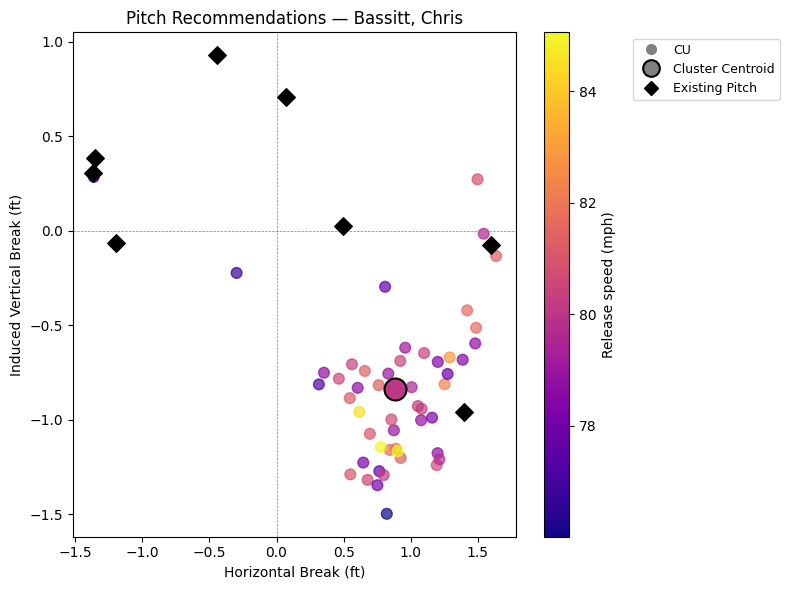

In [60]:
plot_pitch_clusters(comp)

## Testing

In [61]:
r_johnson = suggest_pitches(
    target_pitcher='Johnson, Ryan',
    pitcher_summ=pitcher_summ_r,
    pitch_type_summ=pitch_type_summ,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.25,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)
r_johnson['suggestions']

,cluster_label,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,pitch_types_in_cluster,comp_pitchers
0,CU,21,80.1,1.02,-0.96,2.56,80.2,1.02,-0.96,"CU, KC","Barlow, Scott, Bassitt, Chris, Brewer, Colten,..."
1,ST,13,80.9,0.93,-0.26,1.49,81.0,0.92,-0.28,"CH, CU, KC, SL, ST","Bassitt, Chris, Buttó, José, Crick, Kyle, Fedd..."


In [62]:
t_megill = suggest_pitches(
    target_pitcher='Megill, Trevor',
    pitcher_summ=pitcher_summ_r,
    pitch_type_summ=pitch_type_summ,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.25,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)
t_megill['suggestions']

,cluster_label,n_comps,avg_release_speed,avg_pfx_x,avg_pfx_z,avg_min_dist_to_target,wavg_release_speed,wavg_pfx_x,wavg_pfx_z,pitch_types_in_cluster,comp_pitchers
0,CH,46,89.4,-1.09,0.54,2.25,89.3,-1.09,0.56,"CH, FS","Abreu, Albert, Baker, Bryan, Bautista, Félix, ..."
1,SI,23,97.6,-1.23,0.96,1.53,97.7,-1.23,0.97,SI,"Brito, Jhony, Brown, Hunter, Coonrod, Sam, Erc..."
2,CU,22,82.3,0.83,-0.72,1.50,82.4,0.84,-0.74,"CU, KC, SL, ST","Baz, Shane, Bednar, David, Bigge, Hunter, Boyl..."
3,SL,22,90.5,0.36,0.53,1.51,90.5,0.38,0.53,"CU, FC, SL, ST","Baker, Bryan, Baumann, Mike, Bradley, Taj, Bro..."


In [63]:
def run_suggest_pitches_bulk(
    pitcher_summ,
    pitch_type_summ,
    handedness,           # 'R' or 'L'
    min_pitches=20,
    **kwargs,                  # forwarded to suggest_pitches
):
    """
    Run suggest_pitches for every qualifying pitcher and return:
        suggestions_df : flat DataFrame of all suggestions, with target_pitcher column
        diagnostics_df : one row per pitcher with status and basic counts
    """
    pitcher_summ_h = pitcher_summ[pitcher_summ['p_throws'] == handedness]

    # build pool from that
    pool = pitcher_summ_h[(pitcher_summ_h['n'] >= min_pitches) & (pitcher_summ_h['game_year'] == 2025)]

    all_suggestions = []
    diag_rows       = []

    for name in pool['player_name']:
        try:
            result = suggest_pitches(
                name, pitcher_summ_h, pitch_type_summ,
                min_pitches=min_pitches, **kwargs
            )
            status    = result['status']
            n_comps   = len(result['comps'])
            n_suggest = len(result['suggestions'])

            if status == 'ok' and n_suggest > 0:
                sdf = result['suggestions'].copy()
                sdf.insert(0, 'target_pitcher', name)
                all_suggestions.append(sdf)

        except Exception as e:
            status    = f'exception: {e}'
            n_comps   = 0
            n_suggest = 0

        diag_rows.append({
            'target_pitcher': name,
            'status':         status,
            'n_comps':        n_comps,
            'n_suggestions':  n_suggest,
        })

    suggestions_df = (
        pd.concat(all_suggestions, ignore_index=True)
        if all_suggestions else pd.DataFrame()
    )
    diagnostics_df = pd.DataFrame(diag_rows)

    return suggestions_df, diagnostics_df

In [64]:
pitcher_summ.head(2)

,pitcher,p_throws,player_name,game_year,release_pos_x,release_pos_z,release_extension,arm_angle,n,max_velo,max_spin,pri_fb,fb_pfx_x,fb_n,pri_fb_cd,active_spin_fastball,FB_type
0,424144,L,"Pérez, Oliver",2021,2.390893,5.429286,6.178571,22.013043,56,89.211538,2111.055556,SI,1.583846,26.0,0,NaN,NaN
1,424144,L,"Pérez, Oliver",2022,2.498630,5.361370,6.134247,19.002740,73,88.750000,2255.851852,SI,1.468636,44.0,0,NaN,NaN


In [65]:
pitch_type_summ.head(2)

,pitch_type,pitcher,player_name,p_throws,game_year,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,release_spin_rate,release_extension,release_pos_y,spin_axis,arm_angle,n
0,CH,425794,"Wainwright, Adam",R,2021,82.729744,-1.333487,6.222359,-1.152821,0.643179,1714.097938,6.495897,54.000974,222.546392,43.993229,195
1,CH,425794,"Wainwright, Adam",R,2022,82.182540,-1.314709,6.223757,-1.192593,0.668889,1763.634921,6.424339,54.075979,225.285714,42.871429,189


In [66]:
r_default = run_suggest_pitches_bulk(pitcher_summ, pitch_type_summ, handedness='R', min_pitches=20,
                                    biomech_distance_threshold=1.5,  
                                    novelty_distance_threshold=1.25,  
                                    min_comp_usage_pct=0.01)

In [67]:
r_default[1]['n_suggestions'].sum()

np.int64(1273)

In [68]:
#r_default[1].to_csv('/Users/kids/Downloads/bulk_r.csv', index=False)

In [69]:
r_default[1]#[r_default[0]['target_pitcher']=='Johnson, Ryan']

,target_pitcher,status,n_comps,n_suggestions
0,"Verlander, Justin",ok,229,3
1,"Jansen, Kenley",ok,192,2
2,"Chavez, Jesse",ok,31,2
3,"Morton, Charlie",ok,208,2
4,"Scherzer, Max",ok,440,2
...,...,...,...,...
594,"Birdsong, Hayden",ok,426,3
595,"Morales, Luis",ok,228,4
596,"Sasaki, Roki",ok,68,3
597,"Yamamoto, Yoshinobu",ok,502,2


In [70]:
#r_default[1][r_default[1]['status'] != 'ok']
r_default[1][r_default[1]['n_suggestions'] > 2].sort_values('n_comps')

,target_pitcher,status,n_comps,n_suggestions
438,"Roberts, Ethan",ok,10,3
216,"Martinez, Seth",ok,14,3
452,"Uribe, Abner",ok,15,4
510,"Roycroft, Chris",ok,20,3
81,"Scott, Tayler",ok,21,4
...,...,...,...,...
156,"Trivino, Lou",ok,478,3
536,"Rodriguez, Carlos",ok,479,3
311,"Sauer, Matt",ok,490,3
581,"Bivens, Spencer",ok,504,3


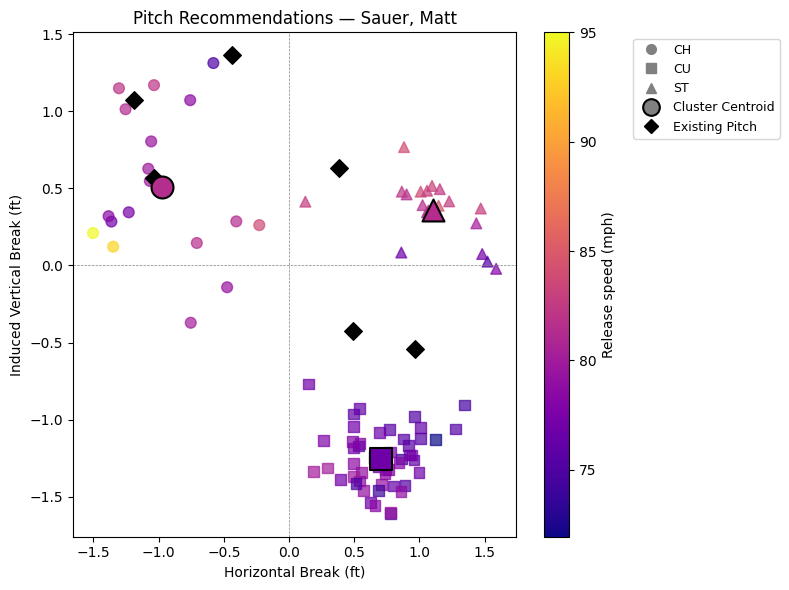

In [71]:
test2 = suggest_pitches(
    target_pitcher='Sauer, Matt',
    pitcher_summ=pitcher_summ_r,
    pitch_type_summ=pitch_type_summ,
    biomech_distance_threshold=1.5,  
    novelty_distance_threshold=1.25,  
    min_comp_usage_pct=0.01,
    min_pitches=20
)
plot_pitch_clusters(test2)

## Hyperparameter Tuning

Initial tuning suggests biomech_distance_threshold=1.5, novelty_distance_threshold=1.25, min_pitches=20

### Arsenal Minimum Distance

In [72]:
def arsenal_internal_distances(pitch_type_summ, pitch_features=PITCH_CHAR_FEATURES):
    """
    For each pitcher, compute the average (and percentiles) of the closest
    distance from each pitch to any other pitch in their arsenal.
    Gives a natural scale for novelty_distance_threshold.
    """
    rows = []
    pitchers = pitch_type_summ['player_name'].unique()

    for name in pitchers:
        arsenal = (
            pitch_type_summ[pitch_type_summ['player_name'] == name]
            .dropna(subset=pitch_features)
            .reset_index(drop=True)
        )
        if len(arsenal) < 2:
            continue

        scaler = StandardScaler().fit(arsenal[pitch_features])
        X = scaler.transform(arsenal[pitch_features].values)

        # Distance matrix; set diagonal to inf so a pitch isn't its own closest
        dist_matrix = cdist(X, X, metric='euclidean')
        np.fill_diagonal(dist_matrix, np.inf)
        min_dists = dist_matrix.min(axis=1)

        rows.append({
            'player_name': name,
            'n_pitches':   len(arsenal),
            'mean_min_dist':   round(min_dists.mean(), 3),
            'min_min_dist':    round(min_dists.min(), 3),
            'p25_min_dist':    round(np.percentile(min_dists, 25), 3),
            'p50_min_dist':    round(np.percentile(min_dists, 50), 3),
            'p75_min_dist':    round(np.percentile(min_dists, 75), 3),
            'p90_min_dist':    round(np.percentile(min_dists, 90), 3),
        })

    df = pd.DataFrame(rows).sort_values('mean_min_dist').reset_index(drop=True)
    
    print("── Arsenal internal distances (across all pitchers) ──")
    print(df[['mean_min_dist', 'min_min_dist', 'p25_min_dist', 'p50_min_dist', 
              'p75_min_dist', 'p90_min_dist']].describe().round(3).to_string())
    
    return df

In [73]:
arsenal = (
            pitch_type_summ[pitch_type_summ['player_name'] == 'Verlander, Justin']
            .dropna(subset=PITCH_CHAR_FEATURES)
            .reset_index(drop=True)
        )
scaler = StandardScaler().fit(arsenal[PITCH_CHAR_FEATURES])
X = scaler.transform(arsenal[PITCH_CHAR_FEATURES].values)
dist_matrix = cdist(X, X, metric='euclidean')
np.fill_diagonal(dist_matrix, np.inf)
min_dists = dist_matrix.min(axis=1)

In [74]:
PITCH_CHAR_FEATURES

['release_speed', 'pfx_x', 'pfx_z']

In [75]:
arsenal

,pitch_type,pitcher,player_name,p_throws,game_year,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,release_spin_rate,release_extension,release_pos_y,spin_axis,arm_angle,n
0,CH,434378,"Verlander, Justin",R,2022,86.246032,-1.844127,6.797460,-1.306349,0.864603,1755.476190,6.133333,54.366825,230.301587,46.241935,63
1,CH,434378,"Verlander, Justin",R,2023,85.189256,-1.705124,6.893058,-1.282231,0.747190,1824.000000,5.999174,54.503471,231.330579,49.395868,121
2,CH,434378,"Verlander, Justin",R,2024,84.001875,-1.700750,7.063125,-1.119250,0.808437,1779.493750,5.966875,54.533125,228.900000,50.582500,160
3,CH,434378,"Verlander, Justin",R,2025,84.678829,-2.018829,7.049730,-1.080000,0.780766,1728.734234,6.041441,54.458874,228.729730,50.932883,222
4,CU,434378,"Verlander, Justin",R,2022,79.035438,-1.768656,6.915193,0.577739,-0.936619,2643.734694,6.039308,54.460041,40.444898,49.474029,491
5,CU,434378,"Verlander, Justin",R,2023,78.245385,-1.590154,6.960500,0.584135,-1.102250,2715.763566,5.958077,54.543654,38.236434,53.127308,520
6,CU,434378,"Verlander, Justin",R,2024,77.623410,-1.655231,7.068353,0.602572,-1.119451,2685.421965,5.955202,54.542168,36.751445,53.173121,346
7,CU,434378,"Verlander, Justin",R,2025,78.470079,-1.973438,7.099948,0.628504,-1.027428,2748.280840,5.996063,54.502205,39.325459,53.298425,381
8,FF,434378,"Verlander, Justin",R,2022,95.019787,-1.522268,7.004741,-0.791286,1.601461,2422.846154,6.078446,54.421225,207.842346,53.639540,1314
9,FF,434378,"Verlander, Justin",R,2023,94.301767,-1.369432,7.029747,-0.664908,1.565438,2428.099460,5.980568,54.518840,205.389360,56.997773,1302


In [76]:
print(dist_matrix)

[[       inf 0.22291345 0.45671076 0.40471581 3.32735875 3.49083532
  3.56123035 3.46762866 1.82234357 1.7733085  1.65353508 1.67386496
  1.508844   1.12104966 1.37652195 2.16336789 2.21864438 2.13343541
  2.14961463 3.23508646]
 [0.22291345        inf 0.29841515 0.27505124 3.1679306  3.32503445
  3.3922807  3.30532313 2.01860615 1.95810481 1.84055885 1.8628521
  1.71810569 1.32140821 1.57824531 2.13265471 2.17512801 2.09744783
  2.11801023 3.11789028]
 [0.45671076 0.29841515        inf 0.12981351 2.99095508 3.15133178
  3.21432486 3.12756547 2.11352877 2.02836785 1.90583201 1.94041437
  1.89111048 1.41630389 1.70361346 1.99574849 2.030292   1.94183395
  1.97224782 2.90245961]
 [0.40471581 0.27505124 0.12981351        inf 2.97169942 3.13624738
  3.20285773 3.11078834 2.01364581 1.92667891 1.80903131 1.84034839
  1.79251807 1.32735646 1.60315086 1.9108812  1.95012996 1.8639123
  1.89036328 2.87173558]
 [3.32735875 3.1679306  2.99095508 2.97169942        inf 0.2239345
  0.31341745 0.1520

In [77]:
min_dists

array([0.22291345, 0.22291345, 0.12981351, 0.12981351, 0.1520906 ,
       0.10570395, 0.11069394, 0.10570395, 0.20624461, 0.11616372,
       0.10069988, 0.10069988, 0.35750603, 0.36456557, 0.35750603,
       0.08151004, 0.13625005, 0.08189761, 0.08151004, 1.04040461])

In [78]:
arsenal_internal_distances(pitch_type_summ)

── Arsenal internal distances (across all pitchers) ──
       mean_min_dist  min_min_dist  p25_min_dist  p50_min_dist  p75_min_dist  p90_min_dist
count       1594.000      1594.000      1594.000      1594.000      1594.000      1594.000
mean           0.911         0.637         0.689         0.817         1.030         1.239
std            0.844         0.840         0.813         0.823         0.891         0.927
min            0.108         0.011         0.047         0.073         0.142         0.184
25%            0.300         0.095         0.165         0.239         0.354         0.498
50%            0.464         0.180         0.268         0.378         0.553         0.812
75%            1.513         1.032         1.046         1.363         1.774         1.983
max            3.464         3.464         3.464         3.464         3.464         3.464


,player_name,n_pitches,mean_min_dist,min_min_dist,p25_min_dist,p50_min_dist,p75_min_dist,p90_min_dist
0,"Nola, Aaron",25,0.108,0.044,0.069,0.079,0.142,0.184
1,"Bednar, David",16,0.126,0.066,0.079,0.104,0.181,0.192
2,"Espino, Paolo",19,0.129,0.036,0.070,0.089,0.189,0.225
3,"Middleton, Keynan",9,0.139,0.078,0.116,0.120,0.152,0.213
4,"García, Jarlín",8,0.143,0.054,0.087,0.125,0.184,0.225
...,...,...,...,...,...,...,...,...
1589,"Stallings, Jacob",2,3.464,3.464,3.464,3.464,3.464,3.464
1590,"Alberto, Hanser",2,3.464,3.464,3.464,3.464,3.464,3.464
1591,"Hernández, Enrique",2,3.464,3.464,3.464,3.464,3.464,3.464
1592,"McKinstry, Zach",2,3.464,3.464,3.464,3.464,3.464,3.464


### Biomechanical Minimum Distance

In [79]:
def biomech_threshold_coverage(
    pitcher_summ,
    thresholds=(1.0, 1.5, 2.0, 2.5, 3.0),
    min_pitches=100,
    biomech_features=BIOMECH_FEATURES,
):
    """
    For each threshold, compute the distribution of comp counts across all
    pitchers. Helps pick a biomech_distance_threshold that gives reasonable
    coverage without pulling in dissimilar pitchers.
    """
    biomech_dist = compute_euclidean_distances(
        pitcher_summ,
        features=biomech_features,
        label_cols=['player_name'],
        min_pitches=min_pitches,
    )
    
    pitchers = pitcher_summ[
        pitcher_summ['n'] >= min_pitches
    ]['player_name'].unique()

    rows = []
    for threshold in thresholds:
        comp_counts = []
        for name in pitchers:
            mask = (
                (biomech_dist['player_name1'] == name) |
                (biomech_dist['player_name2'] == name)
            )
            n_comps = (
                biomech_dist[mask]['distance'] <= threshold
            ).sum()
            comp_counts.append(n_comps)

        comp_counts = np.array(comp_counts)
        return comp_counts
        rows.append({
            'threshold':    threshold,
            'mean_comps':   round(comp_counts.mean(), 1),
            'p10_comps':    int(np.percentile(comp_counts, 10)),
            'p25_comps':    int(np.percentile(comp_counts, 25)),
            'p50_comps':    int(np.percentile(comp_counts, 50)),
            'p75_comps':    int(np.percentile(comp_counts, 75)),
            'pct_zero':     round((comp_counts == 0).mean() * 100, 1),
            'pct_lt5':      round((comp_counts < 5).mean() * 100, 1),
        })

    df = pd.DataFrame(rows)
    print("── Biomech threshold coverage ──")
    print(df.to_string(index=False))
    return df

In [80]:
pitcher_summ.head()

,pitcher,p_throws,player_name,game_year,release_pos_x,release_pos_z,release_extension,arm_angle,n,max_velo,max_spin,pri_fb,fb_pfx_x,fb_n,pri_fb_cd,active_spin_fastball,FB_type
0,424144,L,"Pérez, Oliver",2021,2.390893,5.429286,6.178571,22.013043,56,89.211538,2111.055556,SI,1.583846,26.0,0,NaN,NaN
1,424144,L,"Pérez, Oliver",2022,2.498630,5.361370,6.134247,19.002740,73,88.750000,2255.851852,SI,1.468636,44.0,0,NaN,NaN
2,425794,R,"Wainwright, Adam",2021,-1.195318,6.292470,6.478433,46.499203,3037,89.050985,2840.411298,SI,-1.061773,863.0,0,76.4,FF
3,425794,R,"Wainwright, Adam",2022,-1.119490,6.303870,6.419000,46.148490,3080,88.566476,2777.854856,SI,-1.085446,874.0,0,75.8,FF
4,425794,R,"Wainwright, Adam",2023,-1.246479,6.218935,6.475293,45.361083,1690,86.875000,2663.096110,SI,-1.104411,560.0,0,76.9,FF


In [81]:
biomech_threshold_coverage(pitcher_summ_r, 
                           min_pitches=20)

array([ 10,  28, 112, ..., 742,  79, 176], shape=(1153,))

In [82]:
biomech_threshold_coverage(pitcher_summ_l,
                           min_pitches=20)

array([  0,  70,  69,  57,  47,  19,   6,   2,  32,  10, 156,  65, 196,
       114, 157,  12,   3,  91,  23, 191, 245,   0, 166,  10,  32,  38,
       103, 148,  87,  95,  41,  17, 410,  30,  48, 436, 343, 177,  46,
        37,  21,  32, 119,   0,   0,   9,  51,  88, 120,   5,  95,  10,
        42, 240, 245, 247,  81, 223,   0, 197,  51,  18, 291,  18, 148,
        48,   0,  18,  92, 129,   0, 358, 214,  44, 149,   0,  44,   0,
         7,  20, 426, 179,  89, 202, 108, 227, 214,  21,   5,  89,   0,
        85,   6, 400,  61,  60, 118, 128, 104,  35,   0,  63, 275,  10,
        17,  53,  90, 344,  53,  32, 171,  73, 367, 330, 318,   5, 121,
        61, 337,   4,  54, 318, 192,   9,  49,  39,  18, 259,  46,  35,
       273, 223, 358, 131,   6,   0, 120,  74,  93, 103,   0,  14,   0,
       239,  39,   0, 124,   9,  60,  45,   0,  46,  33, 278, 160,  31,
        32, 315,  42, 395, 436,  35, 145,  98, 219,  20,  17,  49,  46,
        23,  31,   9,  10,  64, 100, 173,   1,   6, 177, 206,  9

In [83]:
BIOMECH_FEATURES

['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball']

In [84]:
biomech_dist_l = compute_euclidean_distances(
        pitcher_summ_l,
        features=BIOMECH_FEATURES,
        label_cols=['player_name'],
        min_pitches=20,
        include_features=True
    )

In [85]:
biomech_dist_l[(biomech_dist_l['distance']>1.499) & (biomech_dist_l['distance']<1.501)]

,player_name1,player_name2,distance,release_extension1,release_extension2,arm_angle1,arm_angle2,max_velo1,max_velo2,active_spin_fastball1,active_spin_fastball2
69868,"Detwiler, Ross","Williamson, Brandon",1.499011,-1.763854,-0.813984,0.364760,0.537785,-0.180267,0.702682,0.315175,1.046779
69869,"Heaney, Andrew","Strahm, Matt",1.499024,-0.032047,-0.294664,-1.090883,-0.595101,-1.146336,0.236440,1.036618,0.894361
69870,"Cleavinger, Garrett","Skubal, Tarik",1.499044,-0.322727,-0.218569,-0.627935,0.752131,1.329875,0.808116,0.477753,0.721622
69871,"Banda, Anthony","McClanahan, Shane",1.499044,-0.333239,1.009041,-0.293834,0.337360,1.304414,1.501011,0.680977,0.772427
69872,"Chafin, Andrew","Sánchez, Cristopher",1.499052,0.777030,1.676696,1.020634,0.110936,-0.316354,0.429024,0.660655,0.894361
...,...,...,...,...,...,...,...,...,...,...,...
70151,"García, Jarlín","Nardi, Andrew",1.500971,0.303703,1.151153,0.003940,0.620218,0.248011,0.676347,1.006134,0.020501
70152,"Matzek, Tyler","Matz, Steven",1.500989,-0.085644,0.496369,0.564021,-0.303903,0.728950,0.700199,-0.030305,1.046779
70153,"Kikuchi, Yusei","Sánchez, Cristopher",1.500993,1.428835,1.721270,0.279666,-0.298609,1.130032,0.070894,0.101790,0.945167
70154,"Rogers, Taylor","McCarty, Kirk",1.500995,-1.351325,-0.575849,-0.728635,0.455318,0.071520,-0.130469,-0.101433,0.355819


In [86]:
biomech_dist_r = compute_euclidean_distances(
        pitcher_summ_r,
        features=BIOMECH_FEATURES,
        label_cols=['player_name'],
        min_pitches=20,
        include_features=True
    )

In [87]:
biomech_dist_r[(biomech_dist_r['distance']>1.4999) & (biomech_dist_r['distance']<1.5001)]

,player_name1,player_name2,distance,release_extension1,release_extension2,arm_angle1,arm_angle2,max_velo1,max_velo2,active_spin_fastball1,active_spin_fastball2
561313,"Fedde, Erick","Castro, Anthony",1.499900,0.517097,0.839956,-0.396257,-0.283857,-0.774968,0.438463,-1.667964,-2.480624
561314,"Kimbrel, Craig","DeSclafani, Anthony",1.499901,0.722755,0.414964,-1.075654,0.190718,0.591935,-0.126465,0.499129,0.686666
561315,"Burr, Ryan","Daniel, Davis",1.499901,0.993023,0.362826,1.912743,0.626289,0.063326,-0.352807,0.457454,0.301173
561316,"Gibson, Kyle","Ramsey, Lane",1.499901,1.190566,1.059610,0.423704,0.237385,-0.976253,0.263675,-0.084319,0.728341
561317,"Smith, Burch","Wacha, Michael",1.499902,0.867274,0.735531,0.068282,0.958435,0.227707,-0.521110,0.134474,1.072158
...,...,...,...,...,...,...,...,...,...,...,...
561489,"Law, Derek","Pagán, Emilio",1.500095,0.318717,0.946106,1.223803,0.210095,-0.283364,0.595067,0.196986,0.436617
561490,"Pop, Zach","Cabrera, Edward",1.500095,-0.287206,0.268783,-0.201123,-0.165527,0.444145,1.098706,-0.855304,0.374104
561491,"Poppen, Sean","Ortiz, Luis",1.500096,-0.281323,1.004021,-0.962042,-1.225875,0.391223,0.627291,0.665828,-0.021807
561492,"Givens, Mychal","Teng, Kai-Wei",1.500097,-0.714335,-0.181871,-2.264264,-1.092328,0.156915,-0.515884,-1.470008,-1.094934


In [88]:
pitchers = pitcher_summ[
        pitcher_summ['n'] >= 20
    ]['player_name'].unique()
pitchers.shape

(1546,)

In [91]:
mask = (
    (biomech_dist_r['player_name1'] == 'Darvish, Yu') |
    (biomech_dist_r['player_name2'] == 'Darvish, Yu')
)
n_comps = (
    biomech_dist_r[mask]['distance'] <= 1
)

In [92]:
n_comps.sum()

np.int64(1344)

### Minimum Pitches Tuning

In [93]:
def stability_analysis(
    statcast_df,
    features,
    sample_sizes=None,
    n_replicates=50,
    n_pitchers=50,
    group_by_pitch_type=False,
    random_state=42,
):
    """
    For each feature, compute stability across sample sizes by bootstrapping
    pitch-level data and measuring the sampling SD of estimates across replicates.

    Parameters
    ----------
    statcast_df          : pitch-level DataFrame (statcast_25_clean)
    features             : list of feature names to test
    sample_sizes         : list of ints; defaults to [10, 25, 50, 75, 100, 150, 200]
    n_replicates         : bootstrap replicates per sample size
    n_pitchers           : how many groups to sample for the analysis;
                           only groups with >= max(sample_sizes) pitches are eligible
    group_by_pitch_type  : if True, group by (player_name, pitch_type) instead of
                           player_name alone; use for pitch-characteristic features
    random_state         : for reproducibility

    Returns
    -------
    stability_df : aggregated long-format DataFrame with columns
                   [sample_size, feature, mean_se, p25_se, p50_se, p75_se]
    raw_df       : one row per (group, sample_size, feature, replicate-summary)
    """
    if sample_sizes is None:
        sample_sizes = [10, 25, 50, 75, 100, 150, 200]

    min_pitches = max(sample_sizes)
    rng         = np.random.default_rng(random_state)

    group_cols = ['player_name', 'pitch_type'] if group_by_pitch_type else ['player_name']

    pitch_counts = statcast_df.groupby(group_cols).size()
    eligible     = pitch_counts[pitch_counts >= min_pitches].index.tolist()
    n_sample     = min(n_pitchers, len(eligible))
    sampled      = [eligible[i] for i in rng.choice(len(eligible), size=n_sample, replace=False)]

    rows = []
    for key in sampled:
        if group_by_pitch_type:
            name, pitch_type = key
            group_data = statcast_df[
                (statcast_df['player_name'] == name) &
                (statcast_df['pitch_type'] == pitch_type)
            ].reset_index(drop=True)
            label = f"{name} / {pitch_type}"
        else:
            name       = key
            group_data = statcast_df[statcast_df['player_name'] == name].reset_index(drop=True)
            label      = name

        for n in sample_sizes:
            if n > len(group_data):
                continue

            replicate_vals = {f: [] for f in features}
            for _ in range(n_replicates):
                subset = group_data.sample(n=n, replace=False, random_state=None)
                for feature in features:
                    vals = subset[feature].dropna()
                    if len(vals) > 0:
                        replicate_vals[feature].append(vals.mean())

            for feature in features:
                vals = replicate_vals[feature]
                if len(vals) < 2:
                    continue
                vals = np.array(vals)
                rows.append({
                    'group':       label,
                    'sample_size': n,
                    'feature':     feature,
                    'sampling_sd': vals.std(),
                    'mean_est':    round(vals.mean(), 2),
                })

    raw_df = pd.DataFrame(rows)

    stability_df = (
        raw_df.groupby(['sample_size', 'feature'])['sampling_sd']
        .agg(
            mean_se='mean',
            p25_se=lambda x: np.percentile(x, 25),
            p50_se=lambda x: np.percentile(x, 50),
            p75_se=lambda x: np.percentile(x, 75),
        )
        .round(4)
        .reset_index()
    )

    return stability_df, raw_df


def plot_stability(stability_df, population_sds, threshold_pct=0.10):
    """
    Plot sampling SD vs sample size for each feature, with p25-p75 band
    and a feature-specific stability threshold at threshold_pct of population SD.

    Parameters
    ----------
    stability_df    : output of stability_analysis
    population_sds  : dict mapping feature name to its population SD,
                      e.g. {'arm_angle': 8.2, 'release_extension': 0.4, ...}
                      computed within handedness group from pitcher_summ / pitch_type_summ
    threshold_pct   : fraction of population SD to use as stability threshold (default 0.10)
    """
    features = stability_df['feature'].unique()
    ncols    = 2
    nrows    = int(np.ceil(len(features) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), sharey=False)
    axes      = axes.flatten()

    for i, feature in enumerate(features):
        ax  = axes[i]
        sub = stability_df[stability_df['feature'] == feature]

        ax.plot(sub['sample_size'], sub['mean_se'], color='steelblue', lw=2, label='Mean SE')
        ax.fill_between(
            sub['sample_size'], sub['p25_se'], sub['p75_se'],
            alpha=0.25, color='steelblue', label='P25–P75'
        )

        if feature in population_sds:
            threshold = population_sds[feature] * threshold_pct
            ax.axhline(
                threshold, color='firebrick', lw=1, linestyle='--',
                label=f'{int(threshold_pct * 100)}% of pop SD ({threshold:.2f})'
            )

        ax.set_title(feature)
        ax.set_xlabel('Sample size (pitches)')
        ax.set_ylabel('Sampling SD')
        ax.legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Feature stability by sample size', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [94]:
stability_df_biomech, raw_biomech = stability_analysis(statcast_25_clean, 
                                                     ['release_extension', 'arm_angle'],
                                                     sample_sizes = ([5,10,15,20,25,30]),
                                                     n_replicates=100,
                                                     n_pitchers=100
                                                     )
#stability_df_biomech

NameError: name 'statcast_25_clean' is not defined

In [ ]:
raw_biomech.sort_values('sampling_sd')

In [ ]:
population_sds_biomech = {
    'arm_angle':         pitcher_summ['arm_angle'].std(),
    'release_extension': pitcher_summ['release_extension'].std(),
}
plot_stability(stability_df_biomech, population_sds_biomech)

In [ ]:
stability_df_pitch, raw_pitch = stability_analysis(
    statcast_25_clean,
    features=['release_speed', 'pfx_x', 'pfx_z'],
    group_by_pitch_type=True,
    sample_sizes = ([5,10,15,20,25,30]),
    n_replicates=100,
    n_pitchers=100
)
#stability_df_pitch

In [ ]:
population_sds_pitch = {
    'release_speed': pitch_type_summ['release_speed'].std(),
    'pfx_x':         pitch_type_summ['pfx_x'].std(),
    'pfx_z':         pitch_type_summ['pfx_z'].std(),
}
plot_stability(stability_df_pitch, population_sds_pitch)

In [ ]:
stability_df_pitch_ff, raw_pitch_ff = stability_analysis(
    statcast_25_clean[statcast_25_clean['pitch_type']=='FF'],
    features=['release_speed', 
              #'pfx_x', 
              #'pfx_z'
             ],
    group_by_pitch_type=True,
    sample_sizes = ([5,10,15,20,25,30,35,40]),
    n_replicates=100,
    n_pitchers=100
)
#stability_df_pitch

In [ ]:
pitch_type_summ_ff = pitch_type_summ[pitch_type_summ['pitch_type']=='FF']
population_sds_pitch_ff = {
    'release_speed': pitch_type_summ_ff['release_speed'].std(),
    #'pfx_x':         pitch_type_summ_ff['pfx_x'].std(),
    #'pfx_z':         pitch_type_summ_ff['pfx_z'].std(),
}
plot_stability(stability_df_pitch_ff, population_sds_pitch_ff)